In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

# Add scripts directory to path for imports
script_dir = Path('.').resolve()
project_root = script_dir.parent.parent.parent
sys.path.insert(0, str(project_root / 'src' / 'scripts'))

# Import loader
from loader_ir import (
    load_all_ir_data, 
    print_data_summary,
    apply_baseline_correction,
    PLASTIC_TYPES,
    CONTAMINANTS
)

# Scikit-learn imports
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    hamming_loss,
    ConfusionMatrixDisplay
)

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Load IR Spectral Data

In [2]:
# Define data path
raw_data_dir = project_root / 'data' / 'flattened_IR_data' / 'raw'

print(f"Project root: {project_root}")
print(f"Loading data from: {raw_data_dir}")
print()

# Load all IR data
data = load_all_ir_data(str(raw_data_dir), verbose=True)

Project root: C:\Users\Mikey\Desktop\PhD writings\AI washing\AI-edited program file
Loading data from: C:\Users\Mikey\Desktop\PhD writings\AI washing\AI-edited program file\data\flattened_IR_data\raw

Found 788 CSV files in C:\Users\Mikey\Desktop\PhD writings\AI washing\AI-edited program file\data\flattened_IR_data\raw

Wavenumber resolution distribution:
  - 7469 points: 532 files (reference)
  - 1869 points: 256 files

Reference wavenumber range: 399.7 - 4000.2 cm^-1
Number of wavenumber points: 7469

Successfully loaded 788 spectra
Interpolated 256 files to match reference resolution (7469 points)


In [3]:
# Print data summary
print_data_summary(data)


DATA SUMMARY

Spectral Data:
  - Number of samples: 788
  - Number of wavenumber points: 7469
  - Wavenumber range: 399.7 - 4000.2 cm^-1

Plastic Type Distribution:
  - PP: 172 samples
  - LDPE: 188 samples
  - LLDPE: 190 samples
  - HDPE: 238 samples

Contaminant Distribution:
  - BSA: 404 samples
  - Oil: 418 samples
  - Starch: 360 samples
  - CMC: 314 samples
  - Guar: 400 samples
  - Casein: 30 samples

Samples by number of contaminants:
  - 0 contaminants: 90 samples
  - 1 contaminants: 128 samples
  - 2 contaminants: 224 samples
  - 3 contaminants: 104 samples
  - 4 contaminants: 172 samples
  - 5 contaminants: 70 samples



In [4]:
# Extract key arrays
wavenumbers = data['wavenumbers']
spectra = data['spectra']
plastic_labels = data['plastic_labels']  # One-hot encoded (n_samples, 4)
contaminant_labels = data['contaminant_labels']  # Multi-hot encoded (n_samples, 6)
filenames = data['filenames']
plastic_types = data['plastic_types']  # String labels
contaminants_list = data['contaminants_list']  # List of contaminant lists

print(f"Spectra shape: {spectra.shape}")
print(f"  - {spectra.shape[0]} samples")
print(f"  - {spectra.shape[1]} features (wavenumber points)")
print(f"\nWavenumber range: {wavenumbers.min():.1f} - {wavenumbers.max():.1f} cm⁻¹")
print(f"\nPlastic labels shape: {plastic_labels.shape}")
print(f"Contaminant labels shape: {contaminant_labels.shape}")

Spectra shape: (788, 7469)
  - 788 samples
  - 7469 features (wavenumber points)

Wavenumber range: 399.7 - 4000.2 cm⁻¹

Plastic labels shape: (788, 4)
Contaminant labels shape: (788, 6)


## 2. Data Preprocessing

In [5]:
# Apply baseline correction
spectra_corrected = apply_baseline_correction(
    spectra, 
    wavenumbers, 
    method='rubberband',
    verbose=True
)

print(f"\nCorrected spectra shape: {spectra_corrected.shape}")

Applying rubberband baseline correction to 788 spectra...
  Processed 50/788 spectra
  Processed 100/788 spectra
  Processed 150/788 spectra
  Processed 200/788 spectra
  Processed 250/788 spectra
  Processed 300/788 spectra
  Processed 350/788 spectra
  Processed 400/788 spectra
  Processed 450/788 spectra
  Processed 500/788 spectra
  Processed 550/788 spectra
  Processed 600/788 spectra
  Processed 650/788 spectra
  Processed 700/788 spectra
  Processed 750/788 spectra
Baseline correction complete.

Corrected spectra shape: (788, 7469)


In [6]:
# Prepare feature matrix (X) and target variables
X = spectra_corrected

# Convert one-hot plastic labels to single class labels
y_plastic = np.argmax(plastic_labels, axis=1)

# Contaminant labels remain as multi-hot for multi-label classification
y_contaminant = contaminant_labels

print(f"Feature matrix X shape: {X.shape}")
print(f"Plastic type labels y_plastic shape: {y_plastic.shape}")
print(f"Contaminant labels y_contaminant shape: {y_contaminant.shape}")

# Show class distribution
print(f"\nPlastic type distribution:")
unique, counts = np.unique(y_plastic, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {PLASTIC_TYPES[u]}: {c} samples")

Feature matrix X shape: (788, 7469)
Plastic type labels y_plastic shape: (788,)
Contaminant labels y_contaminant shape: (788, 6)

Plastic type distribution:
  PP: 172 samples
  LDPE: 188 samples
  LLDPE: 190 samples
  HDPE: 238 samples


In [7]:
# Split data into training and test sets
# Use a single split to ensure plastic and contaminant labels stay aligned
X_train, X_test, y_plastic_train, y_plastic_test, y_contaminant_train, y_contaminant_test = train_test_split(
    X, y_plastic, y_contaminant,
    test_size=0.2, 
    random_state=RANDOM_STATE, 
    stratify=y_plastic
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 630 samples
Test set: 158 samples


In [8]:
# Note: Random Forest doesn't require feature scaling, but we'll keep the scaler
# for consistency and potential comparison with other models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# For Random Forest, we can use unscaled data (tree-based models are scale-invariant)
# But scaled data won't hurt performance
print(f"Scaled training data mean: {X_train_scaled.mean():.6f}")
print(f"Scaled training data std: {X_train_scaled.std():.6f}")
print("\nNote: Random Forest is scale-invariant, but we scale for consistency.")

Scaled training data mean: -0.000000
Scaled training data std: 0.999866

Note: Random Forest is scale-invariant, but we scale for consistency.


## 3. Random Forest for Plastic Type Classification

In [9]:
# Create and train Random Forest model for plastic type
rf_plastic = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,  # Let trees grow fully
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',  # sqrt(n_features) for classification
    bootstrap=True,
    oob_score=True,  # Out-of-bag score estimation
    random_state=RANDOM_STATE,
    n_jobs=-1  # Use all available cores
)

print("Training Random Forest for Plastic Type Classification...")
rf_plastic.fit(X_train_scaled, y_plastic_train)
print("Training complete!")
print(f"Out-of-bag score: {rf_plastic.oob_score_:.4f}")

Training Random Forest for Plastic Type Classification...
Training complete!
Out-of-bag score: 0.9175


In [10]:
# Predictions on test set
y_plastic_pred = rf_plastic.predict(X_test_scaled)

# Evaluate plastic type classification
print("=" * 60)
print("PLASTIC TYPE CLASSIFICATION RESULTS")
print("=" * 60)

# Accuracy
accuracy_plastic = accuracy_score(y_plastic_test, y_plastic_pred)
print(f"\nAccuracy: {accuracy_plastic:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_plastic_test, y_plastic_pred, target_names=PLASTIC_TYPES))

PLASTIC TYPE CLASSIFICATION RESULTS

Accuracy: 0.8987

Classification Report:
              precision    recall  f1-score   support

          PP       1.00      1.00      1.00        34
        LDPE       0.75      0.95      0.84        38
       LLDPE       0.93      0.74      0.82        38
        HDPE       0.96      0.92      0.94        48

    accuracy                           0.90       158
   macro avg       0.91      0.90      0.90       158
weighted avg       0.91      0.90      0.90       158



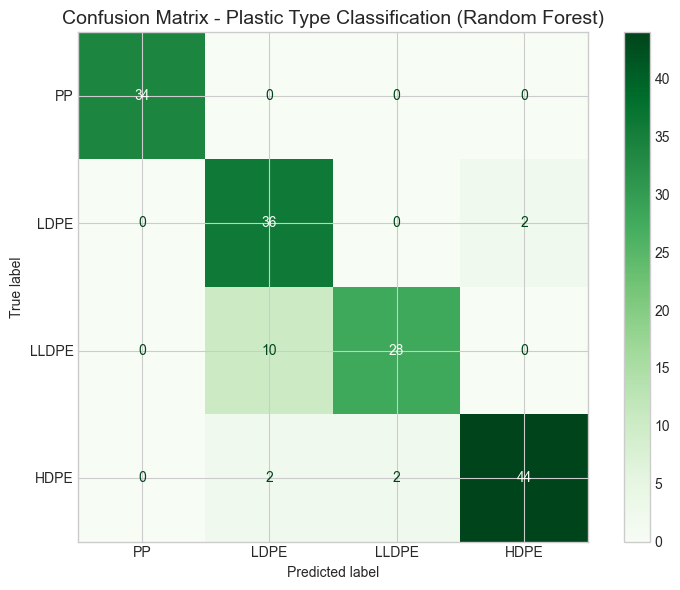

In [11]:
# Confusion matrix for plastic type
cm_plastic = confusion_matrix(y_plastic_test, y_plastic_pred)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_plastic, display_labels=PLASTIC_TYPES)
disp.plot(ax=ax, cmap='Greens', colorbar=True)
ax.set_title('Confusion Matrix - Plastic Type Classification (Random Forest)', fontsize=14)
plt.tight_layout()
plt.savefig(project_root / 'reports' / 'figures' / 'rf_plastic_confusion_matrix.png', dpi=150)
plt.show()

In [12]:
# Cross-validation for plastic type model
print("Performing 5-fold Cross-Validation for Plastic Type Model...")
cv_scores_plastic = cross_val_score(
    rf_plastic, 
    X_train_scaled, 
    y_plastic_train, 
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='accuracy'
)

print(f"\nCross-validation scores: {cv_scores_plastic}")
print(f"Mean CV accuracy: {cv_scores_plastic.mean():.4f} (+/- {cv_scores_plastic.std() * 2:.4f})")

Performing 5-fold Cross-Validation for Plastic Type Model...

Cross-validation scores: [0.8015873  0.84126984 0.82539683 0.86507937 0.88888889]
Mean CV accuracy: 0.8444 (+/- 0.0607)


## 4. Random Forest for Contaminant Detection (Multi-Label)

In [13]:
# Create multi-output Random Forest for contaminant detection
# Using MultiOutputClassifier wrapper for multi-label classification
base_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    bootstrap=True,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_contaminant = MultiOutputClassifier(base_rf, n_jobs=1)  # n_jobs=1 since base estimator uses -1

print("Training Multi-Output Random Forest for Contaminant Detection...")
rf_contaminant.fit(X_train_scaled, y_contaminant_train)
print("Training complete!")

Training Multi-Output Random Forest for Contaminant Detection...
Training complete!


In [14]:
# Predictions on test set
y_contaminant_pred = rf_contaminant.predict(X_test_scaled)

# Evaluate contaminant detection
print("=" * 60)
print("CONTAMINANT DETECTION RESULTS (Multi-Label)")
print("=" * 60)

# Hamming loss (fraction of incorrectly predicted labels)
h_loss = hamming_loss(y_contaminant_test, y_contaminant_pred)
print(f"\nHamming Loss: {h_loss:.4f}")

# Exact match ratio (subset accuracy)
exact_match = accuracy_score(y_contaminant_test, y_contaminant_pred)
print(f"Exact Match Ratio (Subset Accuracy): {exact_match:.4f}")

# Per-label metrics
print("\nPer-Contaminant Performance:")
print("-" * 50)
for i, contaminant in enumerate(CONTAMINANTS):
    acc = accuracy_score(y_contaminant_test[:, i], y_contaminant_pred[:, i])
    f1 = f1_score(y_contaminant_test[:, i], y_contaminant_pred[:, i], zero_division=0)
    print(f"{contaminant:10s}: Accuracy = {acc:.4f}, F1-Score = {f1:.4f}")

CONTAMINANT DETECTION RESULTS (Multi-Label)

Hamming Loss: 0.0401
Exact Match Ratio (Subset Accuracy): 0.8481

Per-Contaminant Performance:
--------------------------------------------------
BSA       : Accuracy = 0.9873, F1-Score = 0.9873
Oil       : Accuracy = 1.0000, F1-Score = 1.0000
Starch    : Accuracy = 0.9241, F1-Score = 0.9143
CMC       : Accuracy = 0.9367, F1-Score = 0.9242
Guar      : Accuracy = 0.9241, F1-Score = 0.9167
Casein    : Accuracy = 0.9873, F1-Score = 0.8889


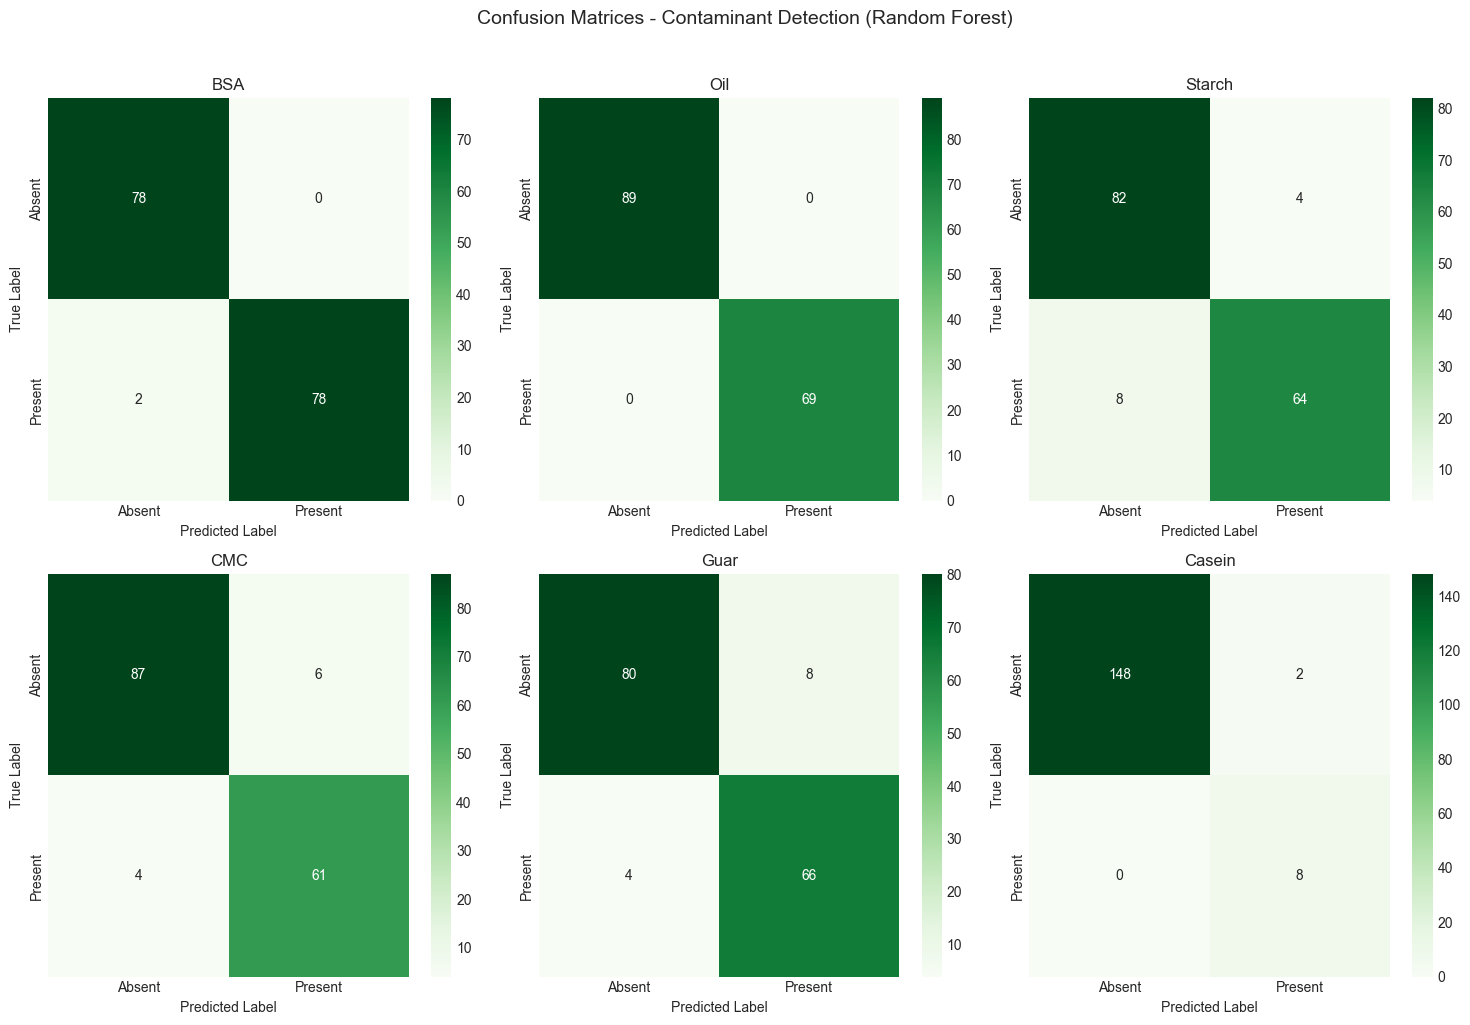

In [15]:
# Confusion matrices for each contaminant
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, (ax, contaminant) in enumerate(zip(axes, CONTAMINANTS)):
    cm = confusion_matrix(y_contaminant_test[:, i], y_contaminant_pred[:, i])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=ax,
                xticklabels=['Absent', 'Present'],
                yticklabels=['Absent', 'Present'])
    ax.set_title(f'{contaminant}', fontsize=12)
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.suptitle('Confusion Matrices - Contaminant Detection (Random Forest)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(project_root / 'reports' / 'figures' / 'rf_contaminant_confusion_matrices.png', dpi=150)
plt.show()

c:\Users\Mikey\anaconda3\envs\CMSE\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Mikey\anaconda3\envs\CMSE\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


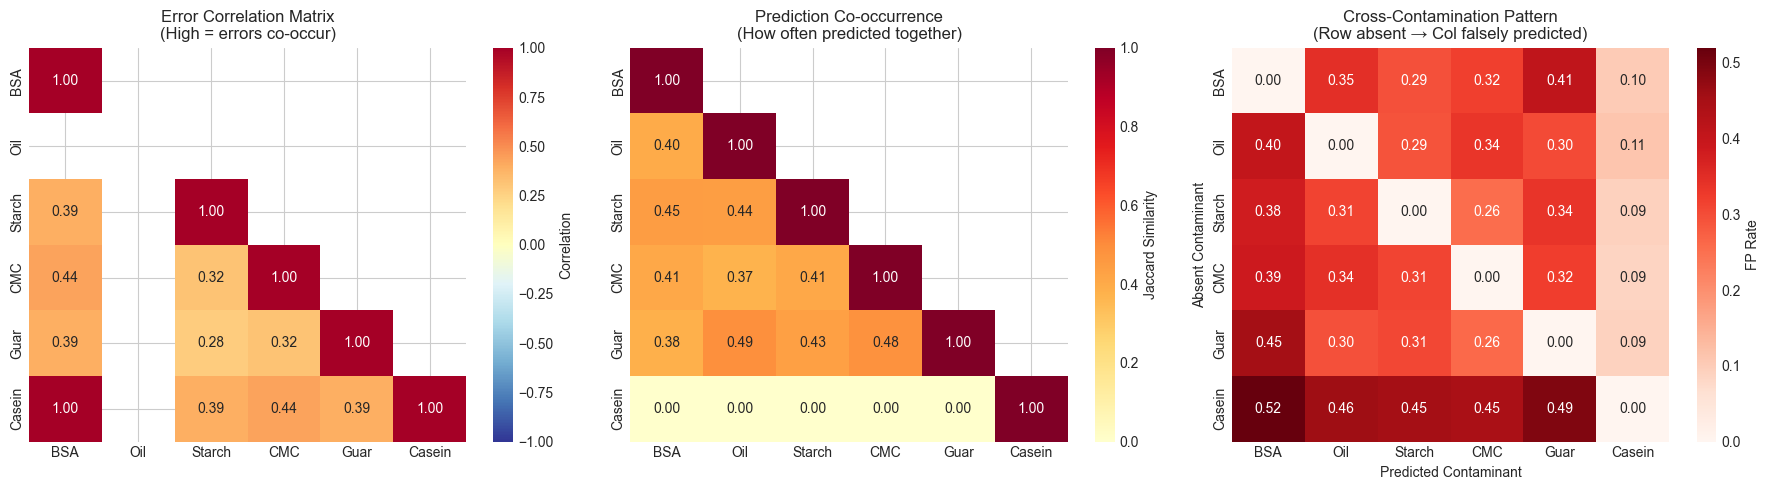


Most correlated error pairs (contaminants often misclassified together):
------------------------------------------------------------
  BSA <-> Casein: correlation = 1.000
  BSA <-> CMC: correlation = 0.436
  CMC <-> Casein: correlation = 0.436
  BSA <-> Guar: correlation = 0.395
  Guar <-> Casein: correlation = 0.395


In [16]:
# Analyze which contaminants are difficult to differentiate from each other
# Using pairwise error correlation and prediction similarity

# 1. Compute error vectors (1 = incorrect prediction, 0 = correct)
errors = (y_contaminant_test != y_contaminant_pred).astype(int)

# 2. Compute pairwise error correlation matrix
# High correlation means when one contaminant is misclassified, the other often is too
error_corr = np.corrcoef(errors.T)

# 3. Compute prediction similarity matrix (Jaccard similarity of predicted labels)
pred_similarity = np.zeros((len(CONTAMINANTS), len(CONTAMINANTS)))
for i in range(len(CONTAMINANTS)):
    for j in range(len(CONTAMINANTS)):
        # How often are both predicted as present together vs. at least one present
        both_present = np.sum((y_contaminant_pred[:, i] == 1) & (y_contaminant_pred[:, j] == 1))
        either_present = np.sum((y_contaminant_pred[:, i] == 1) | (y_contaminant_pred[:, j] == 1))
        pred_similarity[i, j] = both_present / either_present if either_present > 0 else 0

# 4. Create visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Error correlation matrix
mask1 = np.triu(np.ones_like(error_corr, dtype=bool), k=1)
sns.heatmap(error_corr, annot=True, fmt='.2f', cmap='RdYlBu_r', 
            xticklabels=CONTAMINANTS, yticklabels=CONTAMINANTS,
            ax=axes[0], vmin=-1, vmax=1, mask=mask1,
            cbar_kws={'label': 'Correlation'})
axes[0].set_title('Error Correlation Matrix\n(High = errors co-occur)', fontsize=12)

# Plot 2: Prediction similarity (Jaccard)
mask2 = np.triu(np.ones_like(pred_similarity, dtype=bool), k=1)
sns.heatmap(pred_similarity, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=CONTAMINANTS, yticklabels=CONTAMINANTS,
            ax=axes[1], vmin=0, vmax=1, mask=mask2,
            cbar_kws={'label': 'Jaccard Similarity'})
axes[1].set_title('Prediction Co-occurrence\n(How often predicted together)', fontsize=12)

# Plot 3: Confusion pattern - False positive rates when each contaminant is truly absent
fp_when_absent = np.zeros((len(CONTAMINANTS), len(CONTAMINANTS)))
for i in range(len(CONTAMINANTS)):
    for j in range(len(CONTAMINANTS)):
        if i != j:
            # When contaminant i is truly absent, how often is j falsely predicted?
            i_absent = y_contaminant_test[:, i] == 0
            if np.sum(i_absent) > 0:
                fp_when_absent[i, j] = np.mean(y_contaminant_pred[i_absent, j])

sns.heatmap(fp_when_absent, annot=True, fmt='.2f', cmap='Reds',
            xticklabels=CONTAMINANTS, yticklabels=CONTAMINANTS,
            ax=axes[2], vmin=0,
            cbar_kws={'label': 'FP Rate'})
axes[2].set_title('Cross-Contamination Pattern\n(Row absent → Col falsely predicted)', fontsize=12)
axes[2].set_xlabel('Predicted Contaminant')
axes[2].set_ylabel('Absent Contaminant')

plt.tight_layout()
plt.savefig(project_root / 'reports' / 'figures' / 'rf_contaminant_confusion_analysis.png', dpi=150)
plt.show()

# Print summary of most confused pairs
print("\nMost correlated error pairs (contaminants often misclassified together):")
print("-" * 60)
error_pairs = []
for i in range(len(CONTAMINANTS)):
    for j in range(i+1, len(CONTAMINANTS)):
        if not np.isnan(error_corr[i, j]):
            error_pairs.append((CONTAMINANTS[i], CONTAMINANTS[j], error_corr[i, j]))

error_pairs.sort(key=lambda x: abs(x[2]), reverse=True)
for c1, c2, corr in error_pairs[:5]:
    print(f"  {c1} <-> {c2}: correlation = {corr:.3f}")

## 5. Combined Multi-Output Model

In [17]:
# Create combined labels (plastic type + contaminants)
# Plastic type as integer class (0-3) + contaminant binary labels
y_combined_train = np.column_stack([y_plastic_train.reshape(-1, 1), y_contaminant_train])
y_combined_test = np.column_stack([y_plastic_test.reshape(-1, 1), y_contaminant_test])

print(f"Combined labels shape (train): {y_combined_train.shape}")
print(f"Combined labels shape (test): {y_combined_test.shape}")
print(f"\nOutput dimensions:")
print(f"  Column 0: Plastic type (0={PLASTIC_TYPES[0]}, 1={PLASTIC_TYPES[1]}, 2={PLASTIC_TYPES[2]}, 3={PLASTIC_TYPES[3]})")
for i, cont in enumerate(CONTAMINANTS):
    print(f"  Column {i+1}: {cont} (0=absent, 1=present)")

Combined labels shape (train): (630, 7)
Combined labels shape (test): (158, 7)

Output dimensions:
  Column 0: Plastic type (0=PP, 1=LDPE, 2=LLDPE, 3=HDPE)
  Column 1: BSA (0=absent, 1=present)
  Column 2: Oil (0=absent, 1=present)
  Column 3: Starch (0=absent, 1=present)
  Column 4: CMC (0=absent, 1=present)
  Column 5: Guar (0=absent, 1=present)
  Column 6: Casein (0=absent, 1=present)


In [18]:
# Train combined multi-output model
base_rf_combined = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    bootstrap=True,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_combined = MultiOutputClassifier(base_rf_combined, n_jobs=1)

print("Training Combined Multi-Output Random Forest Model...")
rf_combined.fit(X_train_scaled, y_combined_train)
print("Training complete!")

# Predictions
y_combined_pred = rf_combined.predict(X_test_scaled)

Training Combined Multi-Output Random Forest Model...
Training complete!


In [19]:
# Evaluate combined model
print("=" * 60)
print("COMBINED MODEL RESULTS")
print("=" * 60)

# Plastic type (first column)
plastic_acc_combined = accuracy_score(y_combined_test[:, 0], y_combined_pred[:, 0])
print(f"\nPlastic Type Accuracy: {plastic_acc_combined:.4f}")

# Contaminants (remaining columns)
contaminant_h_loss = hamming_loss(y_combined_test[:, 1:], y_combined_pred[:, 1:])
print(f"Contaminant Hamming Loss: {contaminant_h_loss:.4f}")

# Overall exact match ratio - computed manually since accuracy_score doesn't support multiclass-multioutput
# Check if ALL outputs match for each sample
overall_exact_match = np.all(y_combined_test == y_combined_pred, axis=1).mean()
print(f"Overall Exact Match Ratio: {overall_exact_match:.4f}")

COMBINED MODEL RESULTS

Plastic Type Accuracy: 0.8987
Contaminant Hamming Loss: 0.0401
Overall Exact Match Ratio: 0.7975


## 6. Save Model and Results

In [20]:
import joblib
from datetime import datetime

# Create output directories if they don't exist
models_dir = Path('.').resolve()
reports_dir = project_root / 'reports' / 'text_reports'
figures_dir = project_root / 'reports' / 'figures'

models_dir.mkdir(parents=True, exist_ok=True)
reports_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

# Save models
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

joblib.dump(rf_plastic, models_dir / f'rf_plastic_model_{timestamp}.joblib')
joblib.dump(rf_contaminant, models_dir / f'rf_contaminant_model_{timestamp}.joblib')
joblib.dump(rf_combined, models_dir / f'rf_combined_model_{timestamp}.joblib')
joblib.dump(scaler, models_dir / f'scaler_{timestamp}.joblib')

print(f"Models saved to: {models_dir}")

Models saved to: C:\Users\Mikey\Desktop\PhD writings\AI washing\AI-edited program file\src\models\random_forest


In [21]:
# Generate and save text report
report = f"""
================================================================================
RANDOM FOREST MODEL EVALUATION REPORT
================================================================================
Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
Data: IR Spectral Data
Training samples: {X_train.shape[0]}
Test samples: {X_test.shape[0]}
Features: {X_train.shape[1]} (wavenumber points)

Model Parameters:
  - n_estimators: 100
  - max_depth: None (unlimited)
  - max_features: sqrt
  - bootstrap: True

--------------------------------------------------------------------------------
1. PLASTIC TYPE CLASSIFICATION (Multi-class)
--------------------------------------------------------------------------------
Classes: {PLASTIC_TYPES}
Test Accuracy: {accuracy_plastic:.4f}
OOB Score: {rf_plastic.oob_score_:.4f}
Mean CV Accuracy: {cv_scores_plastic.mean():.4f} (+/- {cv_scores_plastic.std() * 2:.4f})

{classification_report(y_plastic_test, y_plastic_pred, target_names=PLASTIC_TYPES)}

--------------------------------------------------------------------------------
2. CONTAMINANT DETECTION (Multi-label)
--------------------------------------------------------------------------------
Contaminants: {CONTAMINANTS}
Hamming Loss: {h_loss:.4f}
Exact Match Ratio: {exact_match:.4f}

Per-contaminant Performance:
"""

for i, contaminant in enumerate(CONTAMINANTS):
    acc = accuracy_score(y_contaminant_test[:, i], y_contaminant_pred[:, i])
    f1 = f1_score(y_contaminant_test[:, i], y_contaminant_pred[:, i], zero_division=0)
    report += f"  {contaminant}: Accuracy={acc:.4f}, F1-Score={f1:.4f}\n"

report += f"""
--------------------------------------------------------------------------------
3. COMBINED MODEL
--------------------------------------------------------------------------------
Plastic Type Accuracy: {plastic_acc_combined:.4f}
Contaminant Hamming Loss: {contaminant_h_loss:.4f}
Overall Exact Match Ratio: {overall_exact_match:.4f}

================================================================================
"""

# Save report
report_path = reports_dir / f'rf_evaluation_report_{timestamp}.txt'
with open(report_path, 'w') as f:
    f.write(report)

print(report)
print(f"\nReport saved to: {report_path}")


RANDOM FOREST MODEL EVALUATION REPORT
Date: 2026-01-03 23:26:19
Data: IR Spectral Data
Training samples: 630
Test samples: 158
Features: 7469 (wavenumber points)

Model Parameters:
  - n_estimators: 100
  - max_depth: None (unlimited)
  - max_features: sqrt
  - bootstrap: True

--------------------------------------------------------------------------------
1. PLASTIC TYPE CLASSIFICATION (Multi-class)
--------------------------------------------------------------------------------
Classes: ['PP', 'LDPE', 'LLDPE', 'HDPE']
Test Accuracy: 0.8987
OOB Score: 0.9175
Mean CV Accuracy: 0.8444 (+/- 0.0607)

              precision    recall  f1-score   support

          PP       1.00      1.00      1.00        34
        LDPE       0.75      0.95      0.84        38
       LLDPE       0.93      0.74      0.82        38
        HDPE       0.96      0.92      0.94        48

    accuracy                           0.90       158
   macro avg       0.91      0.90      0.90       158
weighted avg 

## 7. Feature Importance Analysis

C:\Users\Mikey\AppData\Local\Temp\ipykernel_6512\3751369509.py:61: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Mikey\AppData\Local\Temp\ipykernel_6512\3751369509.py:62: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.savefig(project_root / 'reports' / 'figures' / 'rf_feature_importance_plastic.png', dpi=150)
c:\Users\Mikey\anaconda3\envs\CMSE\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


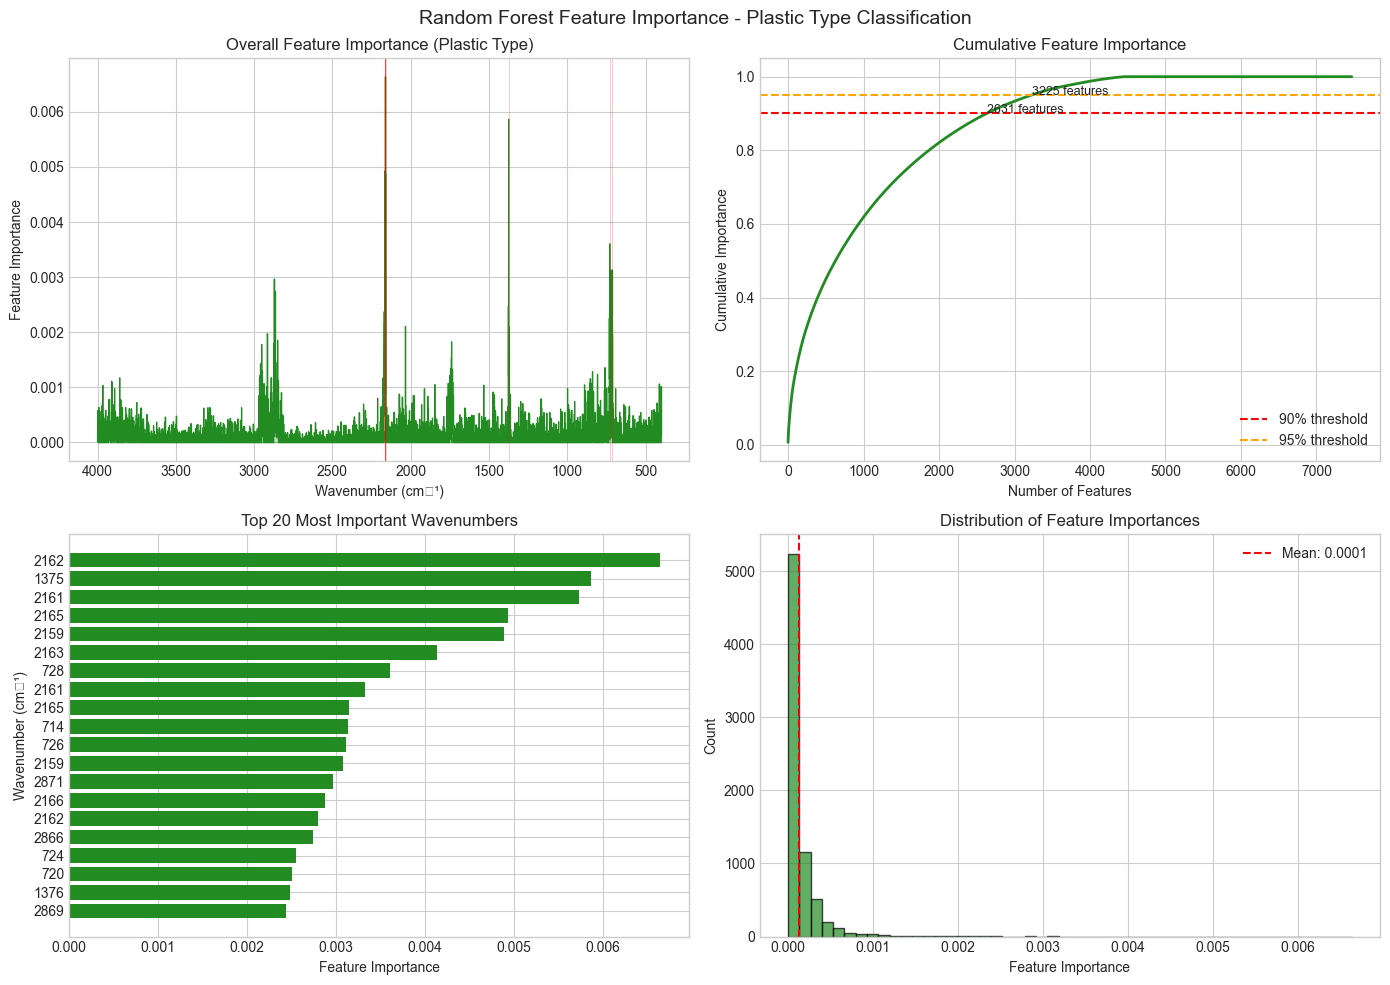


Features needed for 90% importance: 2631 out of 7469
Features needed for 95% importance: 3225 out of 7469


In [22]:
# Visualize feature importance for plastic type model
# This shows which wavenumbers are most important for classification

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Get overall feature importance
importances = rf_plastic.feature_importances_

# Plot overall importance
axes[0].plot(wavenumbers, importances, linewidth=0.8, color='forestgreen')
axes[0].fill_between(wavenumbers, importances, alpha=0.3, color='forestgreen')
axes[0].set_xlabel('Wavenumber (cm⁻¹)', fontsize=10)
axes[0].set_ylabel('Feature Importance', fontsize=10)
axes[0].set_title('Overall Feature Importance (Plastic Type)', fontsize=12)
axes[0].invert_xaxis()  # IR spectra convention

# Find top important wavenumber regions
top_n = 10
top_indices = np.argsort(importances)[-top_n:]
for idx in top_indices:
    axes[0].axvline(x=wavenumbers[idx], color='red', alpha=0.3, linewidth=0.5)

# Plot cumulative importance
sorted_importances = np.sort(importances)[::-1]
cumulative_importance = np.cumsum(sorted_importances)
axes[1].plot(range(len(cumulative_importance)), cumulative_importance, linewidth=2, color='forestgreen')
axes[1].axhline(y=0.9, color='red', linestyle='--', label='90% threshold')
axes[1].axhline(y=0.95, color='orange', linestyle='--', label='95% threshold')
axes[1].set_xlabel('Number of Features', fontsize=10)
axes[1].set_ylabel('Cumulative Importance', fontsize=10)
axes[1].set_title('Cumulative Feature Importance', fontsize=12)
axes[1].legend()

# Find how many features needed for 90% and 95%
n_90 = np.searchsorted(cumulative_importance, 0.9) + 1
n_95 = np.searchsorted(cumulative_importance, 0.95) + 1
axes[1].annotate(f'{n_90} features', xy=(n_90, 0.9), fontsize=9)
axes[1].annotate(f'{n_95} features', xy=(n_95, 0.95), fontsize=9)

# Plot top wavenumbers bar chart
top_20_indices = np.argsort(importances)[-20:]
top_20_wavenumbers = wavenumbers[top_20_indices]
top_20_importances = importances[top_20_indices]
axes[2].barh(range(20), top_20_importances, color='forestgreen')
axes[2].set_yticks(range(20))
axes[2].set_yticklabels([f'{wn:.0f}' for wn in top_20_wavenumbers])
axes[2].set_xlabel('Feature Importance', fontsize=10)
axes[2].set_ylabel('Wavenumber (cm⁻¹)', fontsize=10)
axes[2].set_title('Top 20 Most Important Wavenumbers', fontsize=12)

# Plot importance histogram
axes[3].hist(importances, bins=50, color='forestgreen', edgecolor='black', alpha=0.7)
axes[3].set_xlabel('Feature Importance', fontsize=10)
axes[3].set_ylabel('Count', fontsize=10)
axes[3].set_title('Distribution of Feature Importances', fontsize=12)
axes[3].axvline(x=np.mean(importances), color='red', linestyle='--', label=f'Mean: {np.mean(importances):.4f}')
axes[3].legend()

plt.suptitle('Random Forest Feature Importance - Plastic Type Classification', fontsize=14)
plt.tight_layout()
plt.savefig(project_root / 'reports' / 'figures' / 'rf_feature_importance_plastic.png', dpi=150)
plt.show()

print(f"\nFeatures needed for 90% importance: {n_90} out of {len(importances)}")
print(f"Features needed for 95% importance: {n_95} out of {len(importances)}")

C:\Users\Mikey\AppData\Local\Temp\ipykernel_6512\72978569.py:24: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Mikey\AppData\Local\Temp\ipykernel_6512\72978569.py:25: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.savefig(project_root / 'reports' / 'figures' / 'rf_feature_importance_contaminant.png', dpi=150)
c:\Users\Mikey\anaconda3\envs\CMSE\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


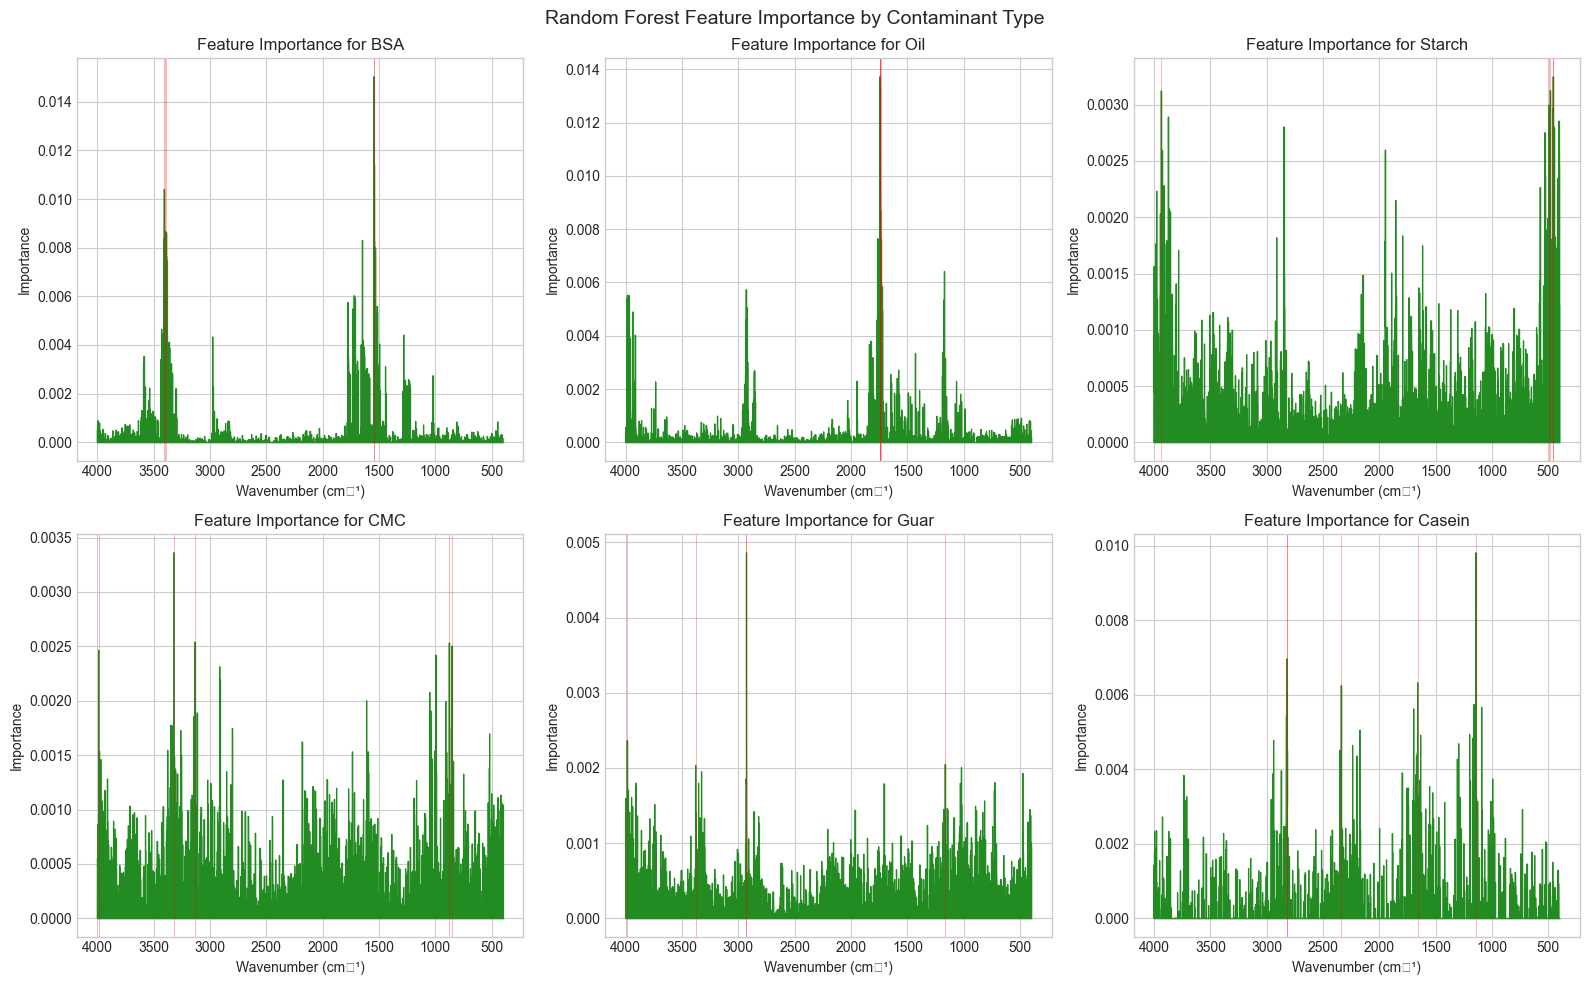

In [23]:
# Visualize feature importance for contaminant detection model
# This shows which wavenumbers are most important for detecting each contaminant

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (ax, contaminant) in enumerate(zip(axes, CONTAMINANTS)):
    # Each estimator in MultiOutputClassifier has feature_importances_
    importances = rf_contaminant.estimators_[i].feature_importances_
    
    ax.plot(wavenumbers, importances, linewidth=0.8, color='forestgreen')
    ax.fill_between(wavenumbers, importances, alpha=0.3, color='forestgreen')
    ax.set_xlabel('Wavenumber (cm⁻¹)', fontsize=10)
    ax.set_ylabel('Importance', fontsize=10)
    ax.set_title(f'Feature Importance for {contaminant}', fontsize=12)
    ax.invert_xaxis()  # IR spectra convention
    
    # Mark top 5 important wavenumbers
    top_5_indices = np.argsort(importances)[-5:]
    for idx in top_5_indices:
        ax.axvline(x=wavenumbers[idx], color='red', alpha=0.4, linewidth=0.5)

plt.suptitle('Random Forest Feature Importance by Contaminant Type', fontsize=14)
plt.tight_layout()
plt.savefig(project_root / 'reports' / 'figures' / 'rf_feature_importance_contaminant.png', dpi=150)
plt.show()

In [24]:
print("Random Forest model training and evaluation complete!")
print(f"\nSummary:")
print(f"  - Plastic Type Classification Accuracy: {accuracy_plastic:.2%}")
print(f"  - Contaminant Detection Hamming Loss: {h_loss:.4f}")
print(f"  - Models saved to: {models_dir}")
print(f"  - Reports saved to: {reports_dir}")
print(f"  - Figures saved to: {figures_dir}")

Random Forest model training and evaluation complete!

Summary:
  - Plastic Type Classification Accuracy: 89.87%
  - Contaminant Detection Hamming Loss: 0.0401
  - Models saved to: C:\Users\Mikey\Desktop\PhD writings\AI washing\AI-edited program file\src\models\random_forest
  - Reports saved to: C:\Users\Mikey\Desktop\PhD writings\AI washing\AI-edited program file\reports\text_reports
  - Figures saved to: C:\Users\Mikey\Desktop\PhD writings\AI washing\AI-edited program file\reports\figures
